## EXO1:

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

df = pd.read_csv('./data/credit_card_fraud_10k.csv')


In [133]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB
None


In [134]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [135]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [136]:
df=df.drop(columns=["transaction_id"])
## id column removed
y=df["is_fraud"]
df=df.drop(columns=["is_fraud"])
## y label column removed
categories=df.drop(columns=["merchant_category"])
df=df.drop(columns=["merchant_category"])
## category removed because generating dummies gives 5 binary columns which affects kmeans since it doesnt work well with binary data

Index(['amount', 'transaction_hour', 'foreign_transaction',
       'location_mismatch', 'device_trust_score', 'velocity_last_24h',
       'cardholder_age'],
      dtype='object')


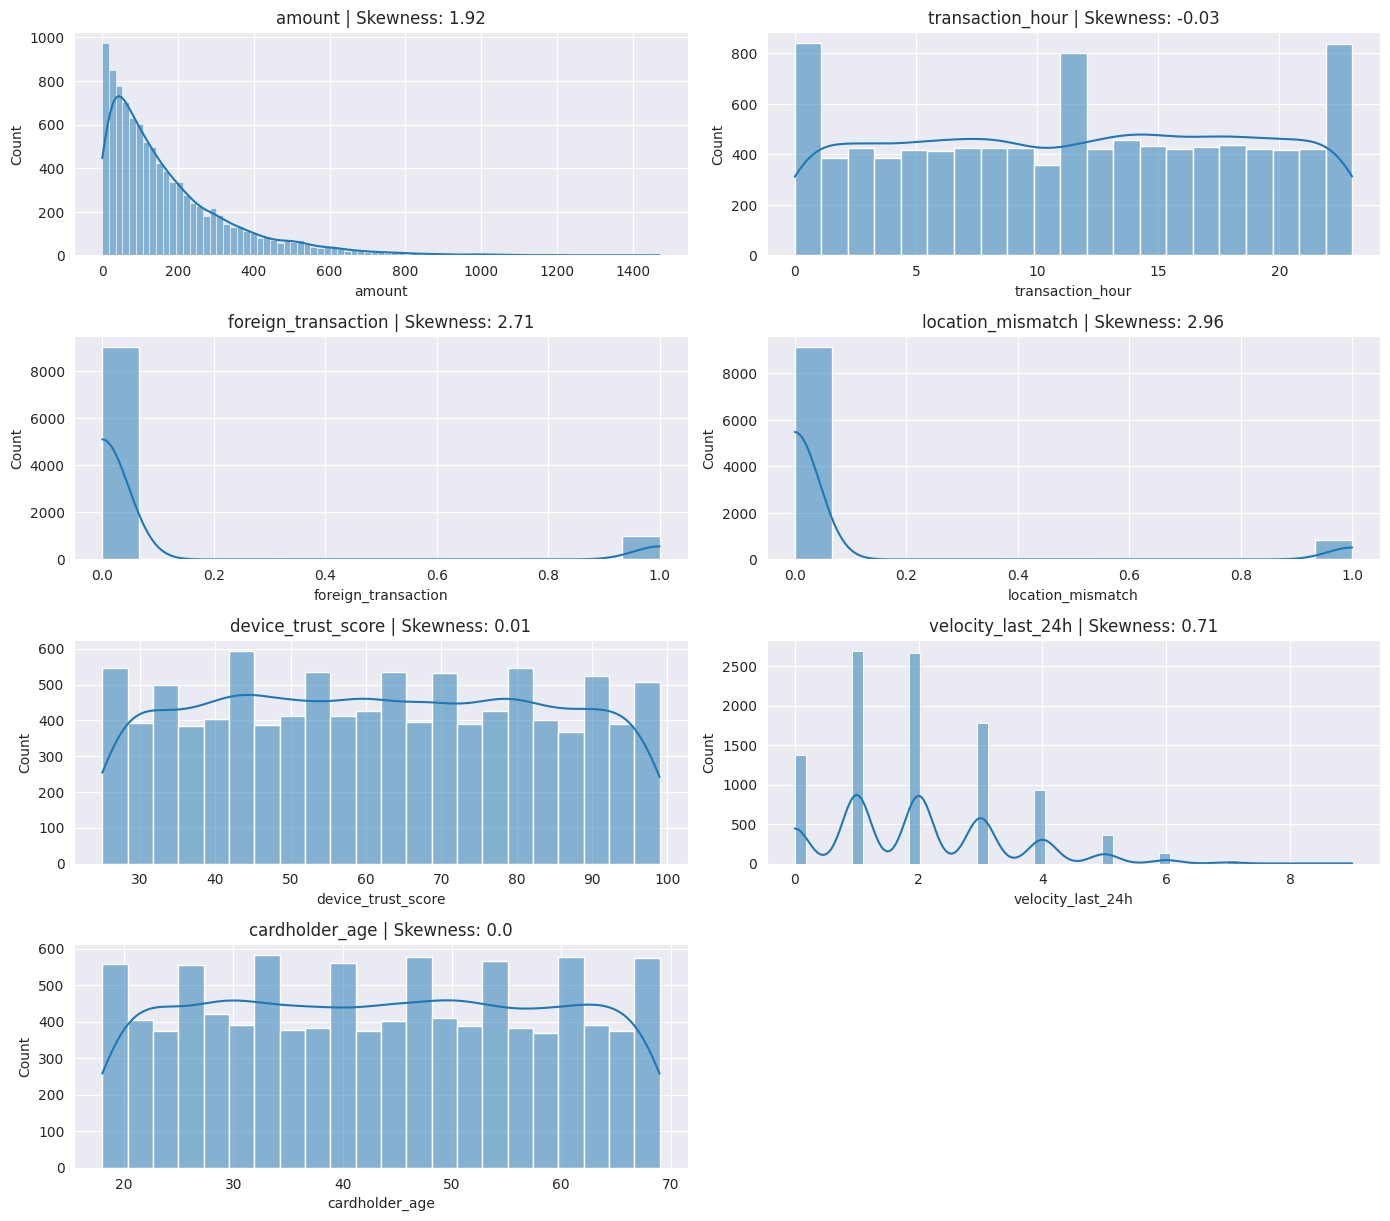

In [137]:
sns.set_style("darkgrid")

numerical_columns = (df.select_dtypes(include=["int64", "float64"]).columns)

print(numerical_columns)
plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

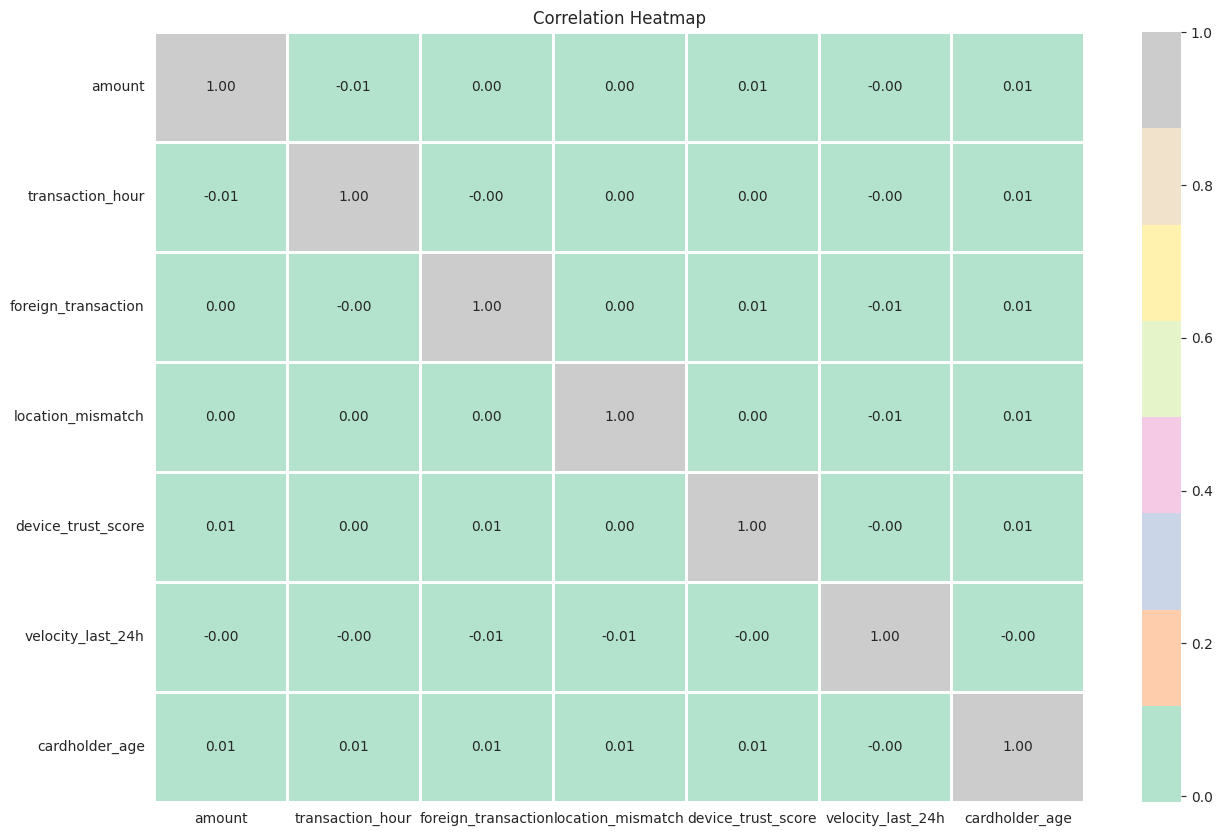

In [138]:
plt.figure(figsize=(15, 10))

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

## Kmeans:

In [139]:
X_scaled = StandardScaler().fit_transform(df) 

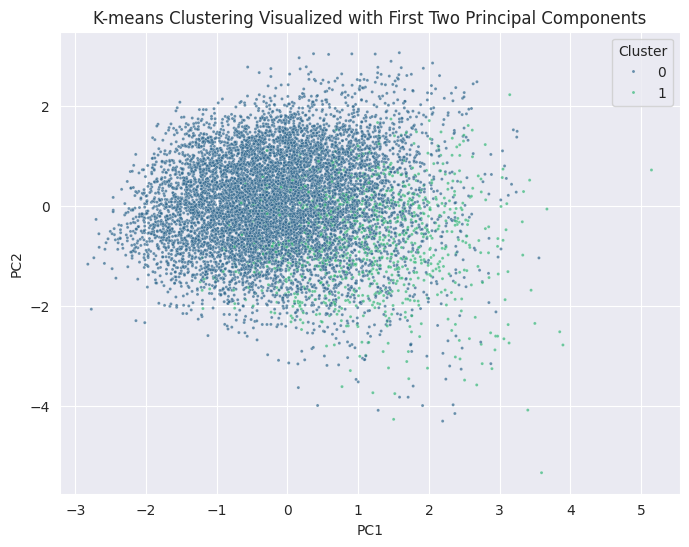

Double checking accuracy using the Y column removed in preprocessing:
0.9035


In [140]:
pca = PCA(n_components=2,random_state=30)
reduced_data = pca.fit_transform(X_scaled)
pca_data = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])


n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, init="k-means++", random_state=10, n_init=10)
kmeans.fit(X_scaled)

pca_data['cluster'] = pd.Categorical(kmeans.labels_)

plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="cluster", data=pca_data, palette="viridis", s=5, alpha=0.7)

plt.title('K-means Clustering Visualized with First Two Principal Components')
plt.xlabel(f'PC1')
plt.ylabel(f'PC2')
plt.legend(title='Cluster')
plt.show()
print("Double checking accuracy using the Y column removed in preprocessing:")
accuracy = accuracy_score(pca_data['cluster'], y)
print(accuracy)

## HCA:

In [141]:
from sklearn.cluster import AgglomerativeClustering
hca_model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
cluster_labels = hca_model.fit_predict(X_scaled)

print("Double checking accuracy using the Y column removed in preprocessing:")
accuracy = accuracy_score(cluster_labels, y)
print(accuracy)

Double checking accuracy using the Y column removed in preprocessing:
0.9136


## DBSCAN:

In [167]:
from sklearn.metrics import silhouette_score
param_grid = {
    'eps': np.arange(0.1, 1.0, 0.1),  # Range for epsilon
    'min_samples': range(2,10)       # Range for min_samples
}

best_score = -1
best_params = {}
two_cluster_params = {}

# 3. Perform the manual grid search
for eps in param_grid['eps']:
    for min_samples in param_grid['min_samples']:
        # Create DBSCAN model
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        
        # Fit and predict clusters
        labels = dbscan.fit_predict(X_scaled)
        
        # Calculate silhouette score only if valid clustering is found (at least 2 clusters and not all noise)
        # DBSCAN assigns -1 to noise points
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters ==2 :
            score = silhouette_score(X_scaled, labels)
            if score > best_score:
                best_score = score
                two_cluster_params = {'eps': eps, 'min_samples': min_samples}
        
                
print(f"Best Silhouette Score: {best_score:.4f}")
print(f"Best Parameters: {two_cluster_params}")

# 4. Use the best parameters to fit the final model
final_dbscan = DBSCAN(**two_cluster_params)
final_labels = final_dbscan.fit_predict(X_scaled)

print(f"Number of clusters found with optimal parameters: {len(set(final_labels)) - (1 if -1 in final_labels else 0)}")




Best Silhouette Score: -0.2640
Best Parameters: {'eps': 0.30000000000000004, 'min_samples': 7}
Number of clusters found with optimal parameters: 2


silhouette score is negative meaning there are misclassified samples in each cluster but it is the best silhouette score possible when forcing dbscan to only have 2 clusters

In [ ]:

arr = np.array(final_labels)

print("Double checking accuracy using the Y column removed in preprocessing:")
accuracy = accuracy_score(arr+1, y)
print(accuracy)


Double checking accuracy using the Y column removed in preprocessing:
0.9835


even though the silhouette score was negative the models accuracy is very high.